# Subgroup Analysis

**Input:** `data/processed/oof_predictions.pkl` + `data/processed/analysis_ready.pkl`
**Output:** DCA plots by subgroup + `outputs/tables/subgroup_actionable_ranges.csv`

This notebook asks whether the decision value of digital biomarkers is **context-dependent**: does adding accelerometer data help more in some patient groups than others?

### Why OOF predictions instead of the held-out test set?

The test set (n=968, ~73 cases) is too small for reliable subgroup DCA. With 4 age bands, the largest subgroup (60-79) has only ~54 cases - barely above the ≥30 minimum for interpretation. Splitting into BMI or sex subgroups makes this worse.

OOF (out-of-fold) predictions cover the full training set (n=3,868, 290 cases). Each participant was scored by a model that never saw them during training, so OOF estimates are unbiased. Population-level DCA results agree between OOF and test set (verified in notebook 04).

> **Reporting:** Subgroup DCA uses OOF predictions (stated explicitly). Population-level metrics and calibration curves (notebook 03) use the held-out test set.

### Notebook outline

| Step | Description |
|------|-------------|
| 1. Load | Merge OOF predictions with demographic features |
| 2. Functions | Net benefit functions (same as notebook 04) |
| 3. Subgroups | Define age band, sex, and BMI subgroups |
| 4. Age bands | DCA by age - the primary stratification |
| 5. Sex | DCA by sex |
| 6. BMI | DCA by BMI category |
| 7. Heatmap | Actionable range summary across all subgroups |
| 8. Findings | Interpret results |

### Reliability note on subgroup DCA

DCA estimates become noisy when subgroups have few outcome events. A subgroup with < 30 cases should be interpreted cautiously - curves will be erratic and confidence intervals (not shown) would be wide. Minimum case counts are printed alongside each plot.

In [2]:
%cd ~/Documents/biomarker-actionability

/Users/mkopy/Documents/biomarker-actionability


## 1. Load Data

`oof_predictions.pkl` carries participant IDs and model predictions for the training set (3,868 participants). Demographic features (age, sex, BMI) live in `analysis_ready.pkl`. Merge on `participant_id` to get everything in one frame.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.options.future.infer_string = False

from src.features import TARGETS

# OOF predictions - primary dataset for subgroup analysis
pred_df = pd.read_pickle('data/processed/oof_predictions.pkl')

# Full feature dataset - pull demographics for OOF participants
features_df = pd.read_pickle('data/processed/analysis_ready.pkl')
demo_cols   = ['participant_id', 'age_years', 'sex', 'bmi', 'race_ethnicity']
demo_df     = features_df[demo_cols]

pred_df = pred_df.merge(demo_df, on='participant_id', how='left')

TARGET     = TARGETS[0]  # 'cvd_hard'
MODEL_KEYS = [c for c in pred_df.columns if c.startswith(('lgbm_', 'tabpfn_'))]

print(f"OOF participants     : {len(pred_df):,}")
print(f"Prevalence (hard CVD): {pred_df[TARGET].mean():.1%}  ({pred_df[TARGET].sum():,} cases)")
print(f"Models               : {MODEL_KEYS}")
print(f"Demographics merged  : {all(c in pred_df.columns for c in ['age_years', 'sex', 'bmi'])}")

OOF participants     : 3,868
Prevalence (hard CVD): 7.5%  (290 cases)
Models               : ['lgbm_biological', 'tabpfn_biological', 'lgbm_digital', 'tabpfn_digital', 'lgbm_combined', 'tabpfn_combined']
Demographics merged  : True


## 2. Net Benefit Functions

In [4]:
def net_benefit(y_true, y_pred, thresholds):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    nb = []
    for t in thresholds:
        pred_pos = y_pred >= t
        tp = np.sum(pred_pos & (y_true == 1))
        fp = np.sum(pred_pos & (y_true == 0))
        nb.append((tp / n) - (fp / n) * (t / (1 - t)))
    return np.array(nb)


def net_benefit_treat_all(y_true, thresholds):
    prev = np.mean(y_true)
    return np.array([prev - (1 - prev) * (t / (1 - t)) for t in thresholds])


def find_actionable_range(y_true, y_pred_base, y_pred_new, thresholds, min_diff=0.005):
    """Threshold range where y_pred_new adds ≥ min_diff NB over y_pred_base and beats treat-all."""
    nb_base = net_benefit(y_true, y_pred_base, thresholds)
    nb_new  = net_benefit(y_true, y_pred_new,  thresholds)
    nb_all  = net_benefit_treat_all(y_true, thresholds)
    better  = (nb_new - nb_base > min_diff) & (nb_new > nb_all) & (nb_new > 0)
    if better.any():
        t = thresholds[better]
        return t.min(), t.max()
    return None


thresholds = np.arange(0.01, 0.31, 0.005)

FEATURE_COLORS = {
    'biological': '#0F6E56',
    'digital':    '#D85A30',
    'combined':   '#185FA5',
}
MIN_CASES_WARNING = 30  # flag subgroups with fewer cases than this

## 3. Define Subgroups

Three stratifications: age band (primary), sex, BMI category. Each is chosen because it plausibly moderates the relationship between physical activity and CVD risk - if digital biomarkers add the most value in middle-aged adults (40–59), that would justify targeted wearable deployment in that group.

In [5]:
pred_df['age_band'] = pd.cut(
    pred_df['age_years'],
    bins=[0, 40, 60, 80, 120],
    labels=['<40', '40–59', '60–79', '80+'],
)
pred_df['sex_label'] = pred_df['sex'].map({1.0: 'Male', 2.0: 'Female'})
pred_df['bmi_category'] = pd.cut(
    pred_df['bmi'],
    bins=[0, 25, 30, 100],
    labels=['Normal (<25)', 'Overweight (25–30)', 'Obese (30+)'],
)

print("Subgroup sizes and hard CVD prevalence:\n")
for col, label in [('age_band', 'Age band'), ('sex_label', 'Sex'), ('bmi_category', 'BMI')]:
    print(f"{label}:")
    for group in pred_df[col].cat.categories if hasattr(pred_df[col], 'cat') else pred_df[col].dropna().unique():
        mask  = pred_df[col] == group
        n     = mask.sum()
        cases = pred_df.loc[mask, TARGET].sum()
        prev  = pred_df.loc[mask, TARGET].mean()
        flag  = ' ⚠ <30 cases' if cases < MIN_CASES_WARNING else ''
        print(f"  {str(group):<22} n={n:>4,}  cases={cases:>3}  prev={prev:.1%}{flag}")
    print()

Subgroup sizes and hard CVD prevalence:

Age band:
  <40                    n=1,691  cases= 10  prev=0.6% ⚠ <30 cases
  40–59                  n=1,163  cases= 62  prev=5.3%
  60–79                  n=1,014  cases=218  prev=21.5%
  80+                    n=   0  cases=  0  prev=nan% ⚠ <30 cases

Sex:
  Female                 n=2,050  cases=128  prev=6.2%
  Male                   n=1,818  cases=162  prev=8.9%

BMI:
  Normal (<25)           n=1,413  cases= 78  prev=5.5%
  Overweight (25–30)     n=1,133  cases= 99  prev=8.7%
  Obese (30+)            n=1,283  cases=108  prev=8.4%



## 4. Decision Curves by Age Band

Age is the dominant CVD risk factor and also the strongest determinant of baseline activity levels. By stratifying on age, we ask: *conditional on knowing a patient's age band, does their wearable data still add decision value?*

Expected pattern:
- **<40**: Very few cases (0.6% prevalence, 10 cases). DCA will be noisy. Any findings are unreliable.
- **40-59**: Most promising band for digital biomarkers. Age alone doesn't explain all risk; activity patterns may carry independent signal.
- **60-79**: High prevalence (21.5%, 218 cases); biological markers dominate. This is the band with the most reliable subgroup DCA.
- **80+**: No participants in this dataset - the PAM subsample excluded participants unable to wear a device for 7 days, which effectively excludes the oldest participants

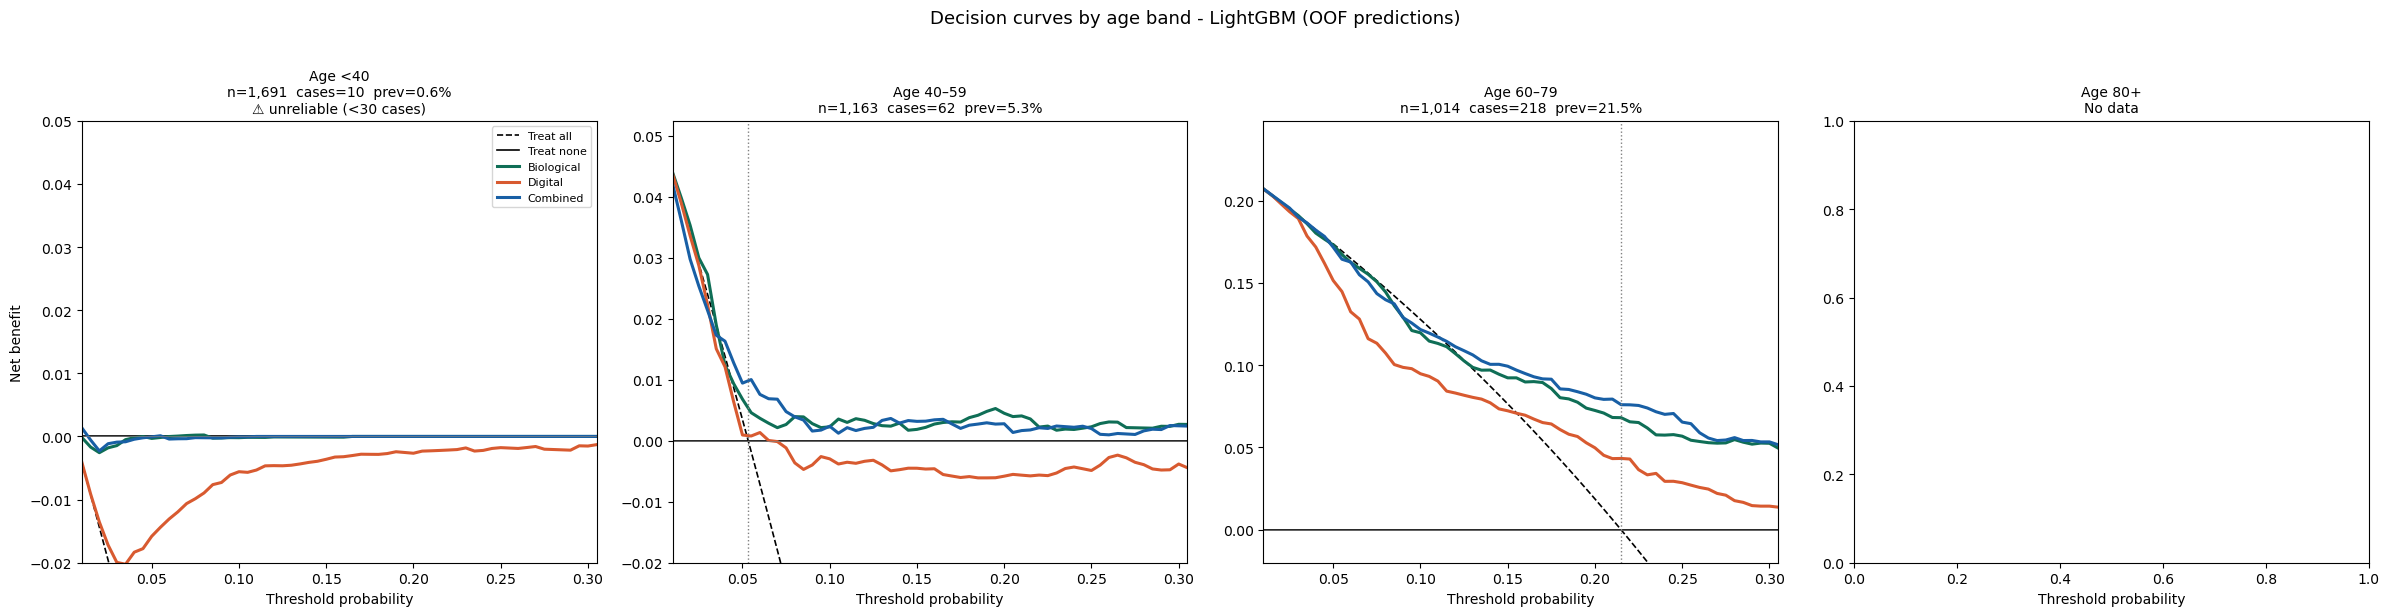

In [6]:
os.makedirs('outputs/figures', exist_ok=True)

age_bands = ['<40', '40–59', '60–79', '80+']
fig, axes  = plt.subplots(1, 4, figsize=(24, 6), sharey=False)

for ax, band in zip(axes, age_bands):
    mask   = pred_df['age_band'] == band
    y_sub  = pred_df.loc[mask, TARGET]
    n      = int(mask.sum())
    cases  = int(y_sub.sum()) if n > 0 else 0

    if n == 0 or cases == 0:
        ax.set_title(f'Age {band}\nNo data', fontsize=10)
        ax.set_xlabel('Threshold probability')
        continue

    prev   = y_sub.mean()
    nb_all = net_benefit_treat_all(y_sub, thresholds)

    ax.plot(thresholds, nb_all,                   'k--', linewidth=1.2, label='Treat all')
    ax.plot(thresholds, np.zeros_like(thresholds), 'k-',  linewidth=1.2, label='Treat none')

    for fs_name, color in FEATURE_COLORS.items():
        key = f'lgbm_{fs_name}'
        if key not in pred_df.columns:
            continue
        nb = net_benefit(y_sub, pred_df.loc[mask, key], thresholds)
        ax.plot(thresholds, nb, color=color, linewidth=2.2, label=fs_name.capitalize())

    ax.axvline(prev, color='grey', linestyle=':', linewidth=1)
    ax.axhline(0, color='grey', linewidth=0.5)

    warning  = '\n⚠ unreliable (<30 cases)' if cases < MIN_CASES_WARNING else ''
    y_upper  = float(np.nanmax(nb_all)) * 1.2
    ax.set_title(f'Age {band}\nn={n:,}  cases={cases}  prev={prev:.1%}{warning}', fontsize=10)
    ax.set_xlabel('Threshold probability')
    ax.set_xlim(thresholds[0], thresholds[-1])
    ax.set_ylim(-0.02, max(y_upper, 0.05))

axes[0].set_ylabel('Net benefit')
axes[0].legend(loc='upper right', fontsize=8)
plt.suptitle('Decision curves by age band - LightGBM (OOF predictions)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/dca_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Decision Curves by Sex

Males have higher hard CVD prevalence in the OOF dataset (8.9% vs 6.2%). This is consistent with known epidemiology and with the broader fasting subsample (21.9% vs 15.0% at participant level before accelerometer filtering). The sex difference matters for DCA because different prevalences shift the treat-all curve and change which threshold range is clinically relevant. If digital biomarkers add value primarily in one sex, this has direct implications for deployment.

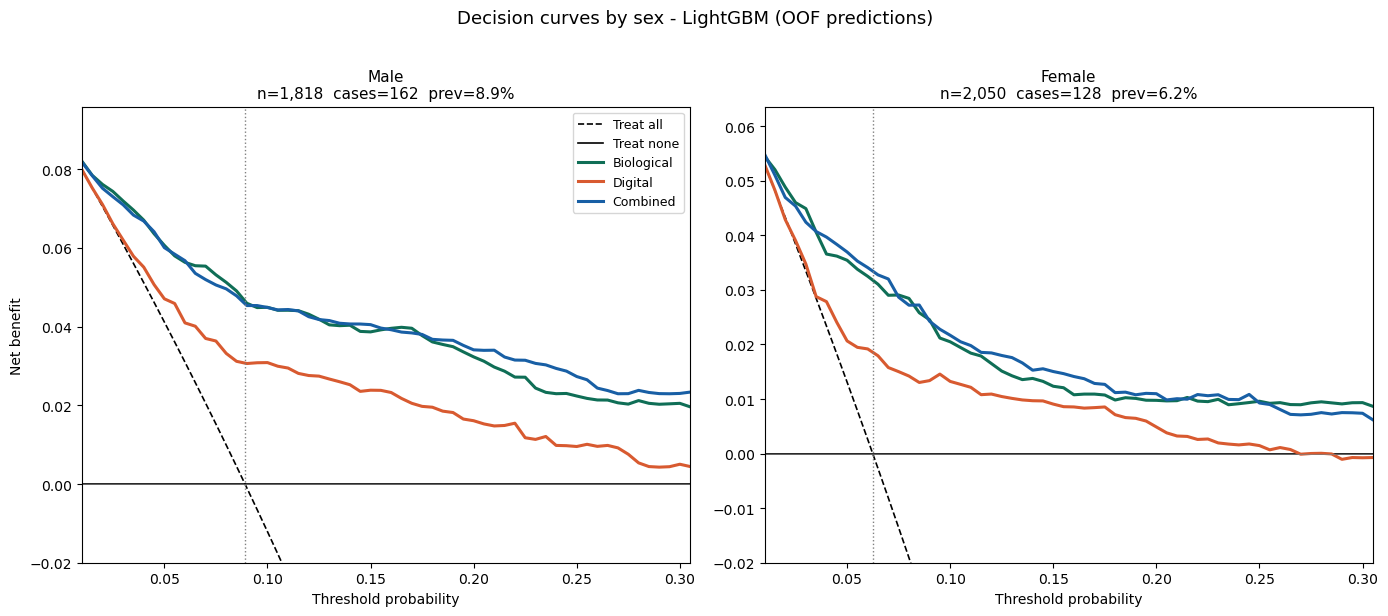

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, sex in zip(axes, ['Male', 'Female']):
    mask  = pred_df['sex_label'] == sex
    y_sub = pred_df.loc[mask, TARGET]
    n     = mask.sum()
    cases = int(y_sub.sum())
    prev  = y_sub.mean()

    nb_all = net_benefit_treat_all(y_sub, thresholds)
    ax.plot(thresholds, nb_all,                   'k--', linewidth=1.2, label='Treat all')
    ax.plot(thresholds, np.zeros_like(thresholds), 'k-', linewidth=1.2, label='Treat none')

    for fs_name, color in FEATURE_COLORS.items():
        key = f'lgbm_{fs_name}'
        if key not in pred_df.columns:
            continue
        nb = net_benefit(y_sub, pred_df.loc[mask, key], thresholds)
        ax.plot(thresholds, nb, color=color, linewidth=2.2, label=fs_name.capitalize())

    ax.axvline(prev, color='grey', linestyle=':', linewidth=1)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_title(f'{sex}\nn={n:,}  cases={cases}  prev={prev:.1%}', fontsize=11)
    ax.set_xlabel('Threshold probability')
    ax.set_xlim(thresholds[0], thresholds[-1])
    ax.set_ylim(-0.02, max(nb_all[0] * 1.2, 0.05))

axes[0].set_ylabel('Net benefit')
axes[0].legend(loc='upper right', fontsize=9)
plt.suptitle('Decision curves by sex - LightGBM (OOF predictions)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/dca_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Decision Curves by BMI Category

Obesity (BMI ≥ 30) is one of the strongest correlates of sedentary behaviour. The hypothesis here is that wearable-derived activity metrics add the most information for overweight and obese individuals - where variation in activity is wider and more prognostically meaningful - and add little for normal-weight individuals where metabolic risk markers are already relatively low.

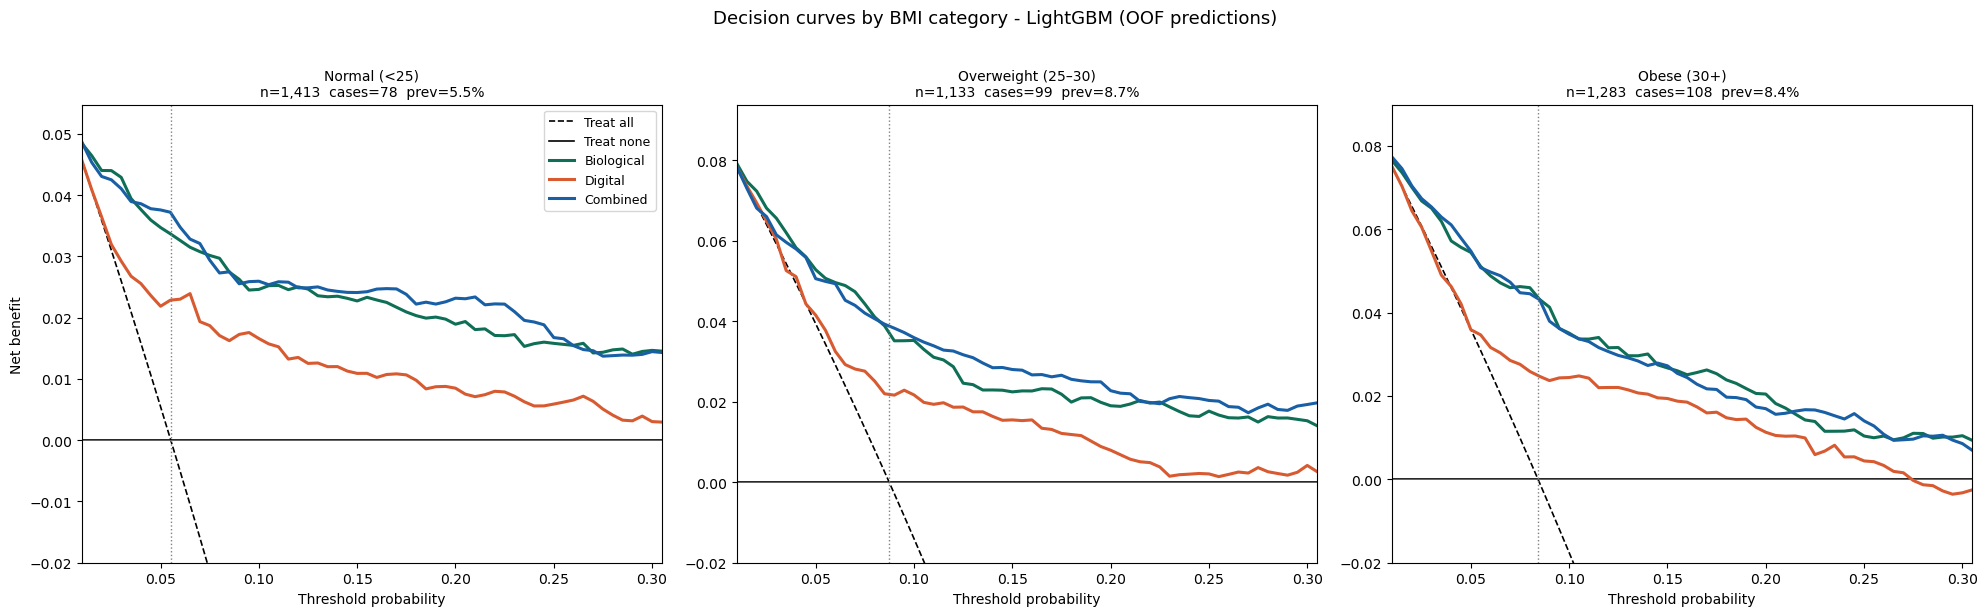

In [8]:
bmi_cats = ['Normal (<25)', 'Overweight (25–30)', 'Obese (30+)']
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for ax, cat in zip(axes, bmi_cats):
    mask  = pred_df['bmi_category'] == cat
    y_sub = pred_df.loc[mask, TARGET]
    n     = mask.sum()
    cases = int(y_sub.sum())
    prev  = y_sub.mean()

    nb_all = net_benefit_treat_all(y_sub, thresholds)
    ax.plot(thresholds, nb_all,                   'k--', linewidth=1.2, label='Treat all')
    ax.plot(thresholds, np.zeros_like(thresholds), 'k-', linewidth=1.2, label='Treat none')

    for fs_name, color in FEATURE_COLORS.items():
        key = f'lgbm_{fs_name}'
        if key not in pred_df.columns:
            continue
        nb = net_benefit(y_sub, pred_df.loc[mask, key], thresholds)
        ax.plot(thresholds, nb, color=color, linewidth=2.2, label=fs_name.capitalize())

    warning = '\n⚠ unreliable (<30 cases)' if cases < MIN_CASES_WARNING else ''
    ax.axvline(prev, color='grey', linestyle=':', linewidth=1)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_title(f'{cat}\nn={n:,}  cases={cases}  prev={prev:.1%}{warning}', fontsize=10)
    ax.set_xlabel('Threshold probability')
    ax.set_xlim(thresholds[0], thresholds[-1])
    ax.set_ylim(-0.02, max(nb_all[0] * 1.2, 0.05))

axes[0].set_ylabel('Net benefit')
axes[0].legend(loc='upper right', fontsize=9)
plt.suptitle('Decision curves by BMI category - LightGBM (OOF predictions)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/dca_by_bmi.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Actionable Range Summary

A single table showing, for every subgroup, whether the combined model beats the biological-only model in any threshold band.

In [9]:
import warnings
warnings.filterwarnings('ignore', message='invalid value encountered')

subgroups = {}
for band in age_bands:
    subgroups[f'Age {band}'] = pred_df['age_band'] == band
for sex in ['Male', 'Female']:
    subgroups[sex] = pred_df['sex_label'] == sex
for cat in bmi_cats:
    subgroups[f'BMI {cat}'] = pred_df['bmi_category'] == cat

rows = []
for group_name, mask in subgroups.items():
    y_sub = pred_df.loc[mask, TARGET]
    n     = int(mask.sum())
    cases = int(y_sub.sum())
    prev  = y_sub.mean()

    r = find_actionable_range(
        y_sub,
        pred_df.loc[mask, 'lgbm_biological'],
        pred_df.loc[mask, 'lgbm_combined'],
        thresholds,
    )
    actionable = f'{r[0]:.3f}–{r[1]:.3f}' if r else '-'
    reliable   = '✓' if cases >= MIN_CASES_WARNING else f'⚠ ({cases} cases)'

    rows.append({
        'Subgroup':          group_name,
        'n':                 n,
        'Cases':             cases,
        'Prevalence':        f'{prev:.1%}',
        'Reliable':          reliable,
        'Actionable range':  actionable,
    })

summary = pd.DataFrame(rows)

os.makedirs('outputs/tables', exist_ok=True)
summary.to_csv('outputs/tables/subgroup_actionable_ranges.csv', index=False)

print("Combined vs Biological - actionable threshold ranges by subgroup:\n")
print(summary.to_string(index=False))
print(f"\nSaved: outputs/tables/subgroup_actionable_ranges.csv")

warnings.resetwarnings()

/var/folders/4y/nymvqk450fqbwplvxh1fsv100000gn/T/ipykernel_13479/4186800563.py:10: RuntimeWarning: invalid value encountered in scalar divide
  nb.append((tp / n) - (fp / n) * (t / (1 - t)))


Combined vs Biological - actionable threshold ranges by subgroup:

              Subgroup    n  Cases Prevalence     Reliable Actionable range
               Age <40 1691     10       0.6% ⚠ (10 cases)                -
             Age 40–59 1163     62       5.3%            ✓      0.055–0.055
             Age 60–79 1014    218      21.5%            ✓      0.125–0.260
               Age 80+    0      0       nan%  ⚠ (0 cases)                -
                  Male 1818    162       8.9%            ✓      0.230–0.245
                Female 2050    128       6.2%            ✓                -
      BMI Normal (<25) 1413     78       5.5%            ✓      0.210–0.225
BMI Overweight (25–30) 1133     99       8.7%            ✓      0.125–0.305
       BMI Obese (30+) 1283    108       8.4%            ✓                -

Saved: outputs/tables/subgroup_actionable_ranges.csv


## 8. Key Findings

Subgroup findings (OOF, n=3,868, 290 cases).

The overall conclusion is a null: adding wearable data to blood markers does not meaningfully shift the screening decision in any demographic subgroup.

The two partial exceptions are adults aged 60-79 (n=1,014, 218 cases, actionable range 0.125–0.260) and the overweight BMI group (n=1,133, 99 cases, 0.125–0.305). These are the groups where screening decisions are genuinely uncertain with prevalence is elevated but treatment is not automatic. Even in these subgroups, the margin above the biological-only curve is small and does not represent a strong case for deploying wearables as a triage tool.

All other subgroups - younger adults, normal-weight individuals, sex strata show either no actionable range or a single-threshold crossing at a very high threshold (>0.26) that is not clinically relevant for population screening.

This reinforces the population-level null: a one-week activity snapshot measured alongside a blood draw captures little that the blood draw did not already reveal. The case for wearable biomarkers rests on longitudinal monitoring and behavioural change detection, not cross-sectional risk stratification.